# Multi-Label Rice Leaf Disease Classification (SVM)

**Goal:** Train on single-disease leaf images (blast-only, brown-spot-only), then test whether the model can correctly name BOTH diseases on composite (multi-disease) leaf images.

Pipeline: Pretrained CNN (frozen feature extractor) -> OneVsRestClassifier(SVM) -> evaluate on composite set.

Edit the paths in Cell 1 to match your Drive structure, then Run All.

In [ ]:
# ============ CELL 1: SETUP + HARDCODED PATHS ============
from google.colab import drive
drive.mount('/content/drive')

import os, glob, time, random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
import joblib

# ---- EDIT THESE PATHS ----
BASE_DIR       = '/content/drive/MyDrive'
BLAST_DIR      = os.path.join(BASE_DIR, 'blast')
BROWN_SPOT_DIR = os.path.join(BASE_DIR, 'brown_spot')
MULTI_DIR      = os.path.join(BASE_DIR, 'augmentation/blast_on_brown_spot_augmented')   # your 900 composite images
MODEL_OUT      = os.path.join(BASE_DIR, 'svm_multilabel_model.joblib')
SCALER_OUT     = os.path.join(BASE_DIR, 'feature_scaler.joblib')

N_PER_CLASS = 900   # sample this many from BLAST_DIR and this many from BROWN_SPOT_DIR for training
SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Blast images available:', len(glob.glob(BLAST_DIR + '/*')))
print('Brown spot images available:', len(glob.glob(BROWN_SPOT_DIR + '/*')))
print('Multi-disease (composite) images:', len(glob.glob(MULTI_DIR + '/*')))

Mounted at /content/drive
Device: cuda
Blast images available: 2758
Brown spot images available: 1389
Multi-disease (composite) images: 900


In [ ]:
# ============ CELL 2: FEATURE EXTRACTOR (frozen ResNet50) ============
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()   # strip classification head -> 2048-d embedding
resnet.eval().to(DEVICE)
for p in resnet.parameters():
    p.requires_grad = False

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_features(paths, batch_size=32):
    feats = []
    valid_paths = []
    batch_imgs, batch_paths = [], []
    def flush():
        if not batch_imgs:
            return
        x = torch.stack(batch_imgs).to(DEVICE)
        with torch.no_grad():
            out = resnet(x).cpu().numpy()
        feats.append(out)
        valid_paths.extend(batch_paths)
    for p in paths:
        try:
            img = Image.open(p).convert('RGB')
            batch_imgs.append(preprocess(img))
            batch_paths.append(p)
        except Exception as e:
            print('Skipping', p, e)
            continue
        if len(batch_imgs) == batch_size:
            flush()
            batch_imgs, batch_paths = [], []
    flush()
    return (np.concatenate(feats, axis=0) if feats else np.empty((0, 2048))), valid_paths

print('Feature extractor ready.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Feature extractor ready.


In [ ]:
# ============ CELL 3: LOAD SINGLE-DISEASE TRAIN DATA (900 sampled per class) ============
t0 = time.time()
random.seed(SEED)

blast_paths_all = sorted(glob.glob(BLAST_DIR + '/*'))
brown_paths_all = sorted(glob.glob(BROWN_SPOT_DIR + '/*'))

blast_paths = random.sample(blast_paths_all, min(N_PER_CLASS, len(blast_paths_all)))
brown_paths = random.sample(brown_paths_all, min(N_PER_CLASS, len(brown_paths_all)))
print(f'Sampled {len(blast_paths)} blast / {len(brown_paths)} brown_spot images for training')

blast_feats, blast_ok = extract_features(blast_paths)
brown_feats, brown_ok = extract_features(brown_paths)

# Labels: [blast, brown_spot]
y_blast = np.tile([1, 0], (len(blast_ok), 1))
y_brown = np.tile([0, 1], (len(brown_ok), 1))

X_train = np.concatenate([blast_feats, brown_feats], axis=0)
y_train = np.concatenate([y_blast, y_brown], axis=0)

print(f'Train features: {X_train.shape}, labels: {y_train.shape}')
print(f'Elapsed: {time.time()-t0:.1f}s')

Sampled 900 blast / 900 brown_spot images for training
Train features: (1800, 2048), labels: (1800, 2)
Elapsed: 497.8s


In [ ]:
# ============ CELL 4: TRAIN MULTI-LABEL SVM ============
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

clf = OneVsRestClassifier(SVC(kernel='rbf', C=10, gamma='scale', probability=True))
clf.fit(X_train_scaled, y_train)

joblib.dump(clf, MODEL_OUT)
joblib.dump(scaler, SCALER_OUT)
print('Model trained and saved to', MODEL_OUT)

Model trained and saved to /content/drive/MyDrive/svm_multilabel_model.joblib


In [ ]:
# ============ CELL 5: EVALUATE ON 900 COMPOSITE (MULTI-DISEASE) IMAGES ============
# NOTE: ground truth here is [1,1] for every composite image since each one
# genuinely contains both diseases. Edit y_true construction if you have
# per-image label files instead.

multi_paths = sorted(glob.glob(MULTI_DIR + '/*'))
multi_feats, multi_ok = extract_features(multi_paths)
multi_feats_scaled = scaler.transform(multi_feats)

y_true = np.tile([1, 1], (len(multi_ok), 1))

probs = clf.predict_proba(multi_feats_scaled)
y_pred = (probs >= 0.5).astype(int)

print('=== Per-label report (blast, brown_spot) ===')
print(classification_report(y_true, y_pred, target_names=['blast', 'brown_spot'], zero_division=0))

exact_match = accuracy_score(y_true, y_pred)  # both labels correct on same image
print(f'Exact match ratio (both diseases correctly named): {exact_match:.3f}')
print(f'Hamming loss: {hamming_loss(y_true, y_pred):.3f}')

# Per-label detection rate on composites (recall is the key number here)
blast_detected = y_pred[:, 0].mean()
brown_detected = y_pred[:, 1].mean()
print(f'Blast detected in composites: {blast_detected*100:.1f}%')
print(f'Brown spot detected in composites: {brown_detected*100:.1f}%')

=== Per-label report (blast, brown_spot) ===
              precision    recall  f1-score   support

       blast       1.00      0.22      0.36       900
  brown_spot       1.00      0.79      0.88       900

   micro avg       1.00      0.50      0.67      1800
   macro avg       1.00      0.50      0.62      1800
weighted avg       1.00      0.50      0.62      1800
 samples avg       1.00      0.50      0.67      1800

Exact match ratio (both diseases correctly named): 0.004
Hamming loss: 0.498
Blast detected in composites: 21.7%
Brown spot detected in composites: 78.8%


In [ ]:
# ============ CELL 6 (OPTIONAL): INSPECT A FEW PREDICTIONS ============
import random
for i in random.sample(range(len(multi_ok)), min(5, len(multi_ok))):
    print(os.path.basename(multi_ok[i]),
          '-> blast:', round(probs[i,0],2), 'brown_spot:', round(probs[i,1],2),
          '| predicted:', y_pred[i])

blast_on_brownspot_brown_spot (305)_multiband_final_aug0.jpg -> blast: 0.81 brown_spot: 0.19 | predicted: [1 0]
blast_on_brownspot_IMG_3245_multiband_final_orig.jpg -> blast: 0.02 brown_spot: 0.98 | predicted: [0 1]
blast_on_brownspot_IMG_20190424_131059_multiband_final_aug0.jpg -> blast: 0.97 brown_spot: 0.03 | predicted: [1 0]
blast_on_brownspot_IMG_20190420_195044_multiband_final_aug1.jpg -> blast: 0.0 brown_spot: 1.0 | predicted: [0 1]
blast_on_brownspot_IMG_20190419_113238_multiband_final_aug3.jpg -> blast: 0.86 brown_spot: 0.13 | predicted: [1 0]


---
## Part 2: Bounding-box detection + labeling

Instead of one label for the whole leaf, this finds each diseased patch, draws a box around it, and labels the box with the predicted disease.

How it works (classical proposal + SVM classify, since we are staying with SVM not a deep detector):
1. Find candidate lesion regions using color segmentation (lesion patches differ in color from healthy green leaf tissue).
2. Crop each candidate region, run it through the same frozen ResNet50 + trained SVM.
3. Keep the box only if the SVM is confident about a disease; label it with whichever class scored higher.

Important caveat: your SVM was trained on whole single-disease leaf images, not on isolated lesion crops. That mismatch may hurt accuracy here. If box labels look unreliable, the fix is retraining the SVM on cropped lesion patches instead of whole leaves.

In [2]:
# ============ RELOAD (skip retraining, load saved model) ============
from google.colab import drive
drive.mount('/content/drive')

import os, glob, random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
import joblib
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

BASE_DIR   = '/content/drive/MyDrive'
MULTI_DIR  = os.path.join(BASE_DIR, 'augmentation/blast_on_brown_spot_augmented')
MODEL_OUT  = os.path.join(BASE_DIR, 'svm_multilabel_model.joblib')
SCALER_OUT = os.path.join(BASE_DIR, 'feature_scaler.joblib')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()
resnet.eval().to(DEVICE)
for p in resnet.parameters():
    p.requires_grad = False

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

clf = joblib.load(MODEL_OUT)
scaler = joblib.load(SCALER_OUT)

multi_ok = sorted(glob.glob(MULTI_DIR + '/*'))
print(f'Loaded model + {len(multi_ok)} composite images. Ready.')

Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


Loaded model + 900 composite images. Ready.


In [3]:
# ============ CELL 7: CANDIDATE LESION REGION PROPOSAL (color-based) ============
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MIN_BOX_AREA = 400

def propose_lesion_boxes(image_path, min_area=MIN_BOX_AREA):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None, []
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([30, 30, 30])
    upper_green = np.array([90, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    lesion_mask = cv2.bitwise_not(green_mask)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    leaf_present = cv2.inRange(gray, 5, 250)
    lesion_mask = cv2.bitwise_and(lesion_mask, leaf_present)

    lesion_mask = cv2.morphologyEx(lesion_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    lesion_mask = cv2.morphologyEx(lesion_mask, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))

    contours, _ = cv2.findContours(lesion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        boxes.append((x, y, w, h))
    return img_bgr, boxes

test_img_path = multi_ok[0]
test_img, test_boxes = propose_lesion_boxes(test_img_path)
print(f'Found {len(test_boxes)} candidate regions in {os.path.basename(test_img_path)}')

Found 6 candidate regions in blast_on_brownspot_BROWNSPOT1_092_multiband_final_aug0.jpg


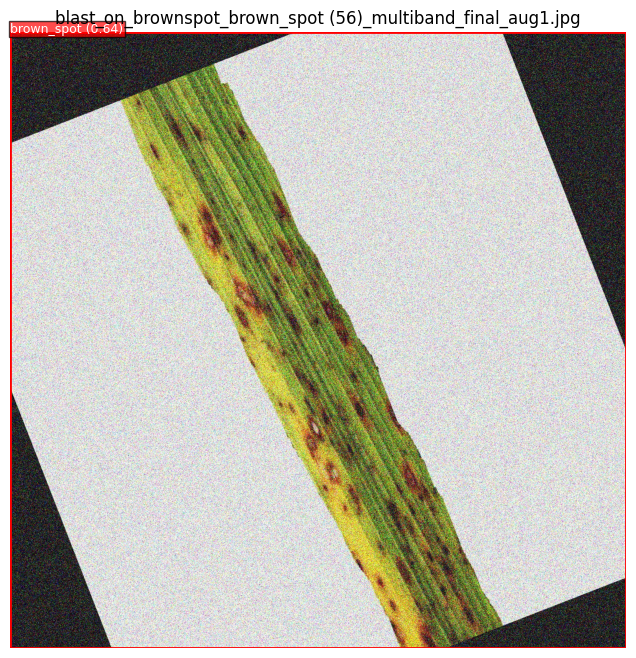

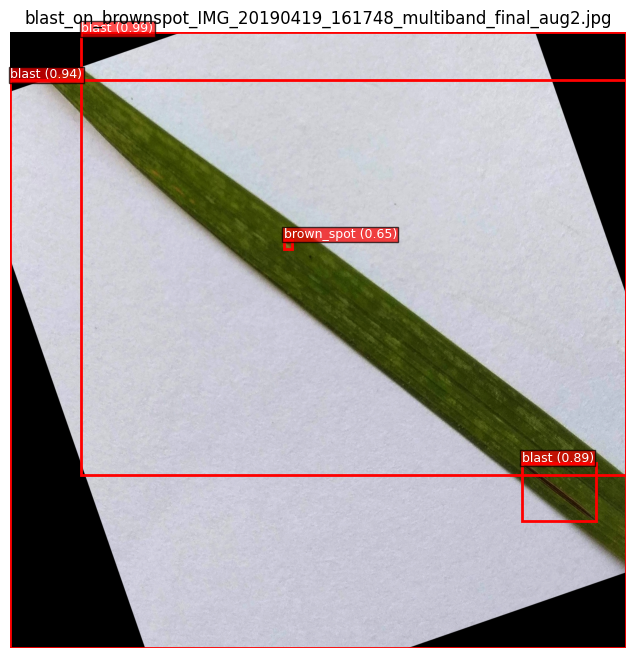

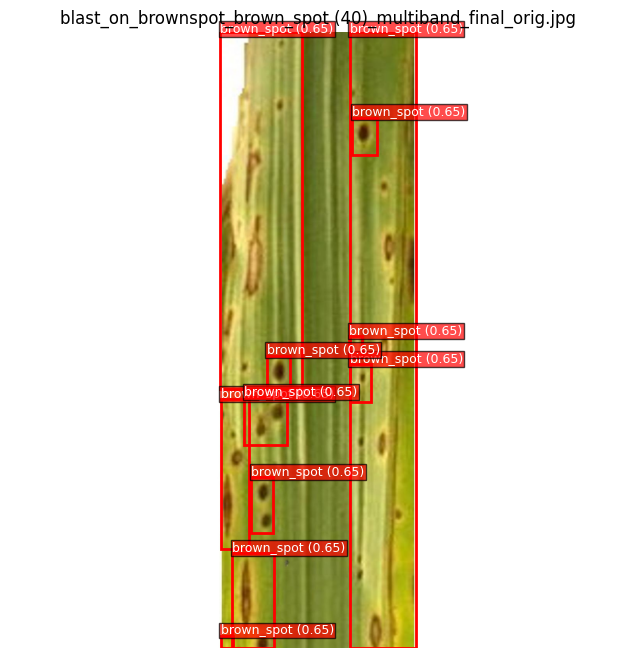

In [4]:
# ============ CELL 8: CLASSIFY EACH BOX + DRAW LABELED BOUNDING BOXES ============
CLASS_NAMES = ['blast', 'brown_spot']
CONF_THRESHOLD = 0.5

def classify_and_draw(image_path, min_area=MIN_BOX_AREA, conf_threshold=CONF_THRESHOLD):
    img_bgr, boxes = propose_lesion_boxes(image_path, min_area)
    if img_bgr is None:
        print('Could not read', image_path)
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img_rgb)

    for (x, y, w, h) in boxes:
        crop = Image.fromarray(img_rgb[y:y+h, x:x+w])
        crop_tensor = preprocess(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feat = resnet(crop_tensor).cpu().numpy()
        feat_scaled = scaler.transform(feat)
        box_probs = clf.predict_proba(feat_scaled)[0]

        best_idx = int(np.argmax(box_probs))
        best_prob = box_probs[best_idx]
        if best_prob < conf_threshold:
            continue

        label = f'{CLASS_NAMES[best_idx]} ({best_prob:.2f})'
        rect = mpatches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(y-5, 0), label, color='white', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.7, pad=1))

    ax.axis('off')
    ax.set_title(os.path.basename(image_path))
    plt.show()

for p in random.sample(multi_ok, min(3, len(multi_ok))):
    classify_and_draw(p)

In [5]:
# ============ CELL 9: DETECTION ACCURACY ACROSS ALL COMPOSITE IMAGES ============
def detect_labels_present(image_path, min_area=MIN_BOX_AREA, conf_threshold=CONF_THRESHOLD):
    img_bgr, boxes = propose_lesion_boxes(image_path, min_area)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    found = np.zeros(len(CLASS_NAMES), dtype=int)

    for (x, y, w, h) in boxes:
        crop = Image.fromarray(img_rgb[y:y+h, x:x+w])
        crop_tensor = preprocess(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feat = resnet(crop_tensor).cpu().numpy()
        feat_scaled = scaler.transform(feat)
        box_probs = clf.predict_proba(feat_scaled)[0]

        best_idx = int(np.argmax(box_probs))
        if box_probs[best_idx] >= conf_threshold:
            found[best_idx] = 1
    return found

y_true_det = []
y_pred_det = []
skipped = 0

for p in multi_ok:
    result = detect_labels_present(p)
    if result is None:
        skipped += 1
        continue
    y_true_det.append([1, 1])   # ground truth: both diseases present
    y_pred_det.append(result)

y_true_det = np.array(y_true_det)
y_pred_det = np.array(y_pred_det)

print(f'Evaluated {len(y_pred_det)} images (skipped {skipped} unreadable)')
print('\n=== Detection-based per-label report (blast, brown_spot) ===')
print(classification_report(y_true_det, y_pred_det, target_names=CLASS_NAMES, zero_division=0))

exact_match_det = accuracy_score(y_true_det, y_pred_det)
print(f'Exact match ratio (both diseases correctly found): {exact_match_det:.3f}')
print(f'Hamming loss: {hamming_loss(y_true_det, y_pred_det):.3f}')
print(f'Blast detected: {y_pred_det[:,0].mean()*100:.1f}%')
print(f'Brown spot detected: {y_pred_det[:,1].mean()*100:.1f}%')

Evaluated 900 images (skipped 0 unreadable)

=== Detection-based per-label report (blast, brown_spot) ===
              precision    recall  f1-score   support

       blast       1.00      0.33      0.49       900
  brown_spot       1.00      0.95      0.98       900

   micro avg       1.00      0.64      0.78      1800
   macro avg       1.00      0.64      0.74      1800
weighted avg       1.00      0.64      0.74      1800
 samples avg       1.00      0.64      0.76      1800

Exact match ratio (both diseases correctly found): 0.281
Hamming loss: 0.359
Blast detected: 32.9%
Brown spot detected: 95.2%
